In [1]:
import pandas as pd
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)
from datasets import Dataset as HFDataset
from evaluate import load as load_metric

from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"

In [2]:
ita = pd.read_csv("dataset/train_it.csv")[["text", "label","bio"]]
eng = pd.read_csv("dataset/train_en.csv")[["text", "label"]]
esp = pd.read_csv("dataset/train_es.csv")[["text", "label"]]

In [3]:
dataset = pd.concat([ita])#,eng,esp])

In [4]:
dataset['bio'].fillna('', inplace=True)

/tmp/ipykernel_103602/2919889901.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['bio'].fillna('', inplace=True)


In [5]:
train_df, test_df = train_test_split(
    dataset,
    test_size=0.3,
    stratify=dataset["label"],
    random_state=42
)

In [6]:
model_name = "Twitter/twhin-bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [7]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        batch["bio"],
        truncation=True,
        padding="max_length",
        max_length=256,
    )


In [8]:
train_ds = HFDataset.from_pandas(train_df).map(tokenize, batched=True)
test_ds = HFDataset.from_pandas(test_df).map(tokenize, batched=True)

Map:   0%|          | 0/760 [00:00<?, ? examples/s]

Map:   0%|          | 0/326 [00:00<?, ? examples/s]

In [9]:
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [10]:
label_counts = train_df["label"].value_counts().to_dict()
total = sum(label_counts.values())
weights = [total / label_counts[i] for i in sorted(label_counts.keys())]
class_weights = torch.tensor(weights, dtype=torch.float)
print(f"Class weights: {class_weights}")

Class weights: tensor([1.2358, 5.2414])


In [11]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to("cuda")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Twitter/twhin-bert-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Il tuo codice per la loss pesata rimane identico
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [13]:
accuracy_metric = load_metric("accuracy")
f1_metric = load_metric("f1")

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels)["f1"],
    }

In [15]:
training_args = TrainingArguments(
    output_dir="./results_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs_weighted",
    logging_steps=50,
    save_total_limit=2,
)

In [16]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/tmp/ipykernel_103602/4027745582.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


In [17]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.
BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.537300,0.450352,0.953988,0.864865
2,0.308800,0.323110,0.960123,0.892562
3,0.220700,0.277963,0.960123,0.897638
4,0.159900,0.307553,0.957055,0.887097
5,0.060500,0.306658,0.966258,0.912000
6,0.001900,0.383697,0.966258,0.910569
7,0.001400,0.418936,0.966258,0.907563
8,0.000300,0.413540,0.963190,0.900000


TrainOutput(global_step=1520, training_loss=0.17341838337811885, metrics={'train_runtime': 150.938, 'train_samples_per_second': 40.281, 'train_steps_per_second': 10.07, 'total_flos': 799857608294400.0, 'train_loss': 0.17341838337811885, 'epoch': 8.0})

In [18]:
import numpy as np
from scipy.special import softmax

# 1. Ottenere le predizioni dal trainer sul dataset di test
# Il trainer usa automaticamente il miglior modello salvato durante il training
# perché hai impostato load_best_model_at_end=True.
predictions_output = trainer.predict(test_ds)

# predictions_output contiene:
# - predictions_output.predictions: i logits (output grezzi del modello) per ogni esempio
# - predictions_output.label_ids: le etichette reali
# - predictions_output.metrics: le metriche calcolate (accuracy, f1, etc.)

print("Metriche sul test set:")
print(predictions_output.metrics)

# 2. Estrarre i dati che ci servono
logits = predictions_output.predictions
true_labels = predictions_output.label_ids

# Convertire i logits in etichette predette (0 o 1)
predicted_labels = np.argmax(logits, axis=-1)

# (Opzionale ma utile) Calcolare le probabilità con softmax per vedere la "confidenza" del modello
probabilities = softmax(logits, axis=1)
confidence_scores = np.max(probabilities, axis=1)

# 3. Creare un DataFrame per l'analisi
# Partiamo da una copia del DataFrame di test originale per mantenere il testo
results_df = test_df.copy()

# Aggiungiamo le nuove colonne con i risultati
results_df['predicted_label'] = predicted_labels
results_df['true_label'] = true_labels # Aggiungiamo anche la vera label per coerenza
results_df['confidence'] = confidence_scores

# Aggiungiamo una colonna booleana per filtrare facilmente gli errori
results_df['is_correct'] = (results_df['true_label'] == results_df['predicted_label'])

# 4. Salvare il DataFrame in un file CSV
output_filename = "error_analysis_results.csv"
results_df.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"\nRisultati salvati in '{output_filename}'")
print("\nAnteprima del DataFrame con i risultati:")
results_df.head()

Metriche sul test set:
{'test_loss': 0.30665823817253113, 'test_accuracy': 0.9662576687116564, 'test_f1': 0.912, 'test_runtime': 1.4051, 'test_samples_per_second': 232.008, 'test_steps_per_second': 58.358}

Risultati salvati in 'error_analysis_results.csv'

Anteprima del DataFrame con i risultati:


,text,label,bio,predicted_label,true_label,confidence,is_correct
243,@USER Non tacciate #katiaricciarelli di omofob...,0,Laureato in Scienze Politiche e delle Relazion...,0,0,0.999492,True
863,"@USER @USER Per qualcuno sono gay,per altri tr...",1,,0,1,0.999676,False
733,Tw // transfobia\n\nporcodio io cerco di non p...,0,"#MADSEASON : I'm above, over you I'm standing ...",0,0,0.999828,True
1,"""Presupporre che tutti i bisessuali non sono m...",0,𝓕𝓲𝓵𝓵𝓮𝓭 𝔀𝓲𝓽𝓱 𝓯𝓾𝓻𝔂 𝓪𝓷𝓭 𝓼𝓽𝓪𝓻𝓻𝔂 𝓮𝔂𝓮𝓭,0,0,0.999822,True
592,con queste modifiche vogliono tagliare fuori l...,0,#loki: a bit of both ...,0,0,0.999829,True


In [19]:
# --- NUOVO CODICE PER L'ANALISI DEGLI ERRORI ---

# Filtra il DataFrame per mostrare solo gli errori
errors_df = results_df[results_df['is_correct'] == False].copy()

print(f"Il modello ha commesso {len(errors_df)} errori su {len(results_df)} esempi di test.")

# Funzione per stampare in modo leggibile
def print_error_details(dataframe):
    """Itera su un dataframe di errori e li stampa in modo formattato."""
    if dataframe.empty:
        print("Nessun errore da mostrare in questa categoria.")
        return
        
    for index, row in dataframe.iterrows():
        print("-" * 50)
        print(f"Confidenza: {row['confidence']:.2%}")
        print(f"Vera Label:    {row['true_label']}")
        print(f"Label Predetta: {row['predicted_label']}")
        print(f"Testo:\n\"{row['text']}\"")
        print("-" * 50 + "\n")

# 1. Analisi degli errori con ALTA confidenza
# Ordiniamo gli errori in modo decrescente per confidenza e prendiamo i primi N
N = 5 # Numero di esempi da mostrare
high_confidence_errors = errors_df.sort_values(by='confidence', ascending=False).head(N)

print("\n" + "="*20 + " TOP 5 ERRORI CON CONFIDENZA PIÙ ALTA " + "="*20)
print("Questi sono i casi in cui il modello era più sicuro di sé, ma ha sbagliato.\nSono molto utili per capire i 'punti ciechi' sistematici del modello.\n")

print_error_details(high_confidence_errors)


# 2. Analisi degli errori con BASSA confidenza
# Ordiniamo gli errori in modo crescente per confidenza e prendiamo i primi N
# Questi sono i casi "borderline"
low_confidence_errors = errors_df.sort_values(by='confidence', ascending=True).head(N)

print("\n" + "="*20 + " TOP 5 ERRORI CON CONFIDENZA PIÙ BASSA " + "="*20)
print("Questi sono i casi in cui il modello era più incerto (confidenza vicina al 50%).\nSono esempi ambigui o difficili da classificare.\n")

print_error_details(low_confidence_errors)

Il modello ha commesso 11 errori su 326 esempi di test.

==================== TOP 5 ERRORI CON CONFIDENZA PIÙ ALTA ====================
Questi sono i casi in cui il modello era più sicuro di sé, ma ha sbagliato.
Sono molto utili per capire i 'punti ciechi' sistematici del modello.

--------------------------------------------------
Confidenza: 99.97%
Vera Label:    1
Label Predetta: 0
Testo:
"IO SONO NATA FROCIA, E NE SONO ORGOGLIOSA.
SUCCHIAMELA FINO ALLA FRUTTA CARA.
FROCI SI NASCE NON SI DIVENTA, TRANS SI NASCE NON SI DIVENTA #FACCIAMORETE
#FASCISTIAPPESIAPIAZZALELORETO"
--------------------------------------------------

--------------------------------------------------
Confidenza: 99.97%
Vera Label:    1
Label Predetta: 0
Testo:
"@USER @USER Per qualcuno sono gay,per altri transgender, per latri ancora LGBT. Per so froci e rottinculo! Bloccatemi vigliacchi di Twitter"
--------------------------------------------------

--------------------------------------------------
Confidenza

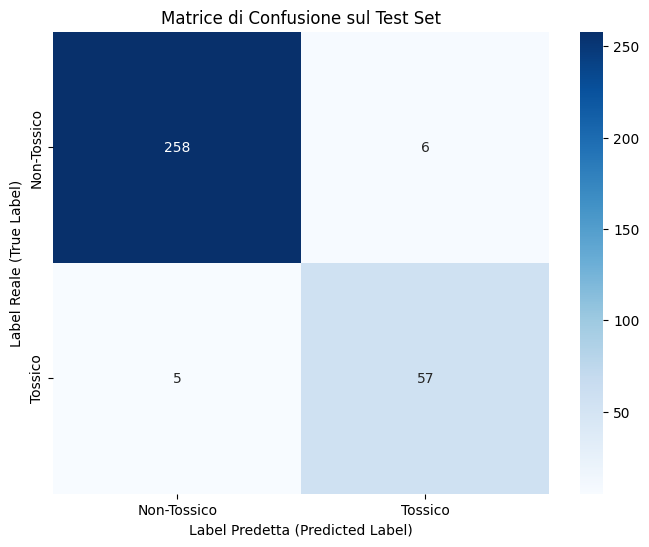

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assicurati che le variabili 'true_labels' e 'predicted_labels'
# siano state definite nel blocco di codice precedente.

# 1. Calcolare la matrice di confusione
cm = confusion_matrix(true_labels, predicted_labels)

# 2. Definire le etichette per gli assi (personalizzale se necessario)
# Assumiamo che 0 = Non-Tossico e 1 = Tossico
class_labels = ['Non-Tossico', 'Tossico']

# 3. Creare il grafico (heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)

# 4. Aggiungere titoli e label per chiarezza
plt.title('Matrice di Confusione sul Test Set')
plt.ylabel('Label Reale (True Label)')
plt.xlabel('Label Predetta (Predicted Label)')

# 5. Mostrare il grafico
plt.show()